In [38]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

## 属性降维

### PCA降维

In [45]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target
print(X.shape)
print(X[:5])
# 初始化PCA，设置主成分数目
pca = PCA(n_components=2)

# 对数据进行PCA降维
X_pca = pca.fit_transform(X)

# 输出降维后的数据形状
print(X_pca.shape)

(150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
(150, 2)


ICA独立成分分析

In [46]:
from sklearn.decomposition import FastICA
print(X.shape)
# 初始化ICA，设置主成分数目
ica = FastICA(n_components=2)
ica.fit(X)
X_ica = ica.transform(X)
print(X_ica.shape)

(150, 4)
(150, 2)


LDA线性判别分析

In [49]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
print(X.shape)
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X, y)
X_kpca = lda.transform(X)
print(X_kpca.shape)

(150, 4)
(150, 2)


## 特征选择
### 过滤法

方差过滤

选取的数据已经被清洗过，所以方差过滤的效果不会太好

In [25]:
data = load_iris()
X = data.data
y = data.target
print(X.shape)
selector = VarianceThreshold(1*10**-40)
x_feature_selection = selector.fit_transform(X)
print(x_feature_selection.shape)

(150, 4)
(150, 4)


相关性过滤 \
卡方过滤

In [27]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# 留下300个特征
X_fschi = SelectKBest(chi2, k=300).fit_transform(X, y)
print(X_fschi.shape)

(150, 4)


d:\Python\CondaEnvs\DataAnalysis\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=300 is greater than n_features=4. All the features will be returned.
  warnings.warn(


使用学习曲线来获得一个最优的超参数K

d:\Python\CondaEnvs\DataAnalysis\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=390 is greater than n_features=4. All the features will be returned.
  warnings.warn(
d:\Python\CondaEnvs\DataAnalysis\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=380 is greater than n_features=4. All the features will be returned.
  warnings.warn(
d:\Python\CondaEnvs\DataAnalysis\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=370 is greater than n_features=4. All the features will be returned.
  warnings.warn(
d:\Python\CondaEnvs\DataAnalysis\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=360 is greater than n_features=4. All the features will be returned.
  warnings.warn(
d:\Python\CondaEnvs\DataAnalysis\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:779: UserWarning: k=350 is greater than n_features=4. All the feat

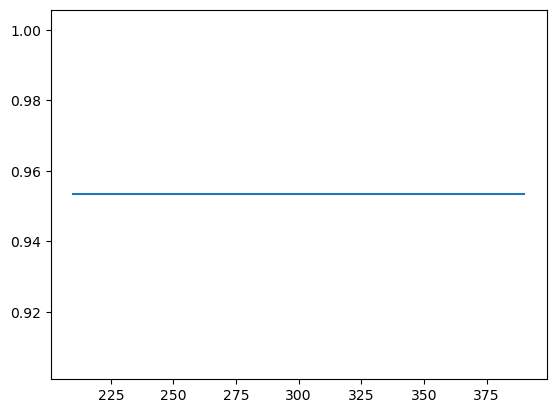

In [28]:
score = []
for i in range(390, 200, -10):
    x_fschi = SelectKBest(chi2, k=i).fit_transform(X, y)
    once = cross_val_score(
        RFC(n_estimators=10, random_state=0), x_fschi, y, cv=5).mean()
    score.append(once)
plt.plot(range(390, 200, -10), score)
plt.show()

In [29]:
chivalue, pvalues_chi = chi2(X, y)
print(chivalue)
print(pvalues_chi)

[ 10.81782088   3.7107283  116.31261309  67.0483602 ]
[4.47651499e-03 1.56395980e-01 5.53397228e-26 2.75824965e-15]


In [30]:
k = chivalue.shape[0] - (pvalues_chi > 0.05).sum()
print(k)

3


F检验

In [31]:
from sklearn.feature_selection import f_classif
F, pvalues_f = f_classif(X, y)
k = F.shape[0] - (pvalues_f > 0.05).sum()
k

np.int64(4)

互信息法

In [32]:
from sklearn.feature_selection import mutual_info_regression as MIC
result = MIC(X, y)
k = X.shape[1] - sum(result <= 0)
k

np.int64(4)

### Embedding嵌入法

In [11]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier as RFC

In [13]:
rfc = RFC()
rfc.fit(X, y)
fi = rfc.feature_importances_
fi

array([3.68063403e-04, 1.55507755e-04, 3.40179337e-06, ...,
       4.08596449e-06, 0.00000000e+00, 3.36483008e-06])

In [14]:
threshold = np.linspace(0, fi.max(), 20)
threshold

array([0.        , 0.0002761 , 0.00055221, 0.00082831, 0.00110442,
       0.00138052, 0.00165663, 0.00193273, 0.00220884, 0.00248494,
       0.00276104, 0.00303715, 0.00331325, 0.00358936, 0.00386546,
       0.00414157, 0.00441767, 0.00469378, 0.00496988, 0.00524598])

In [35]:
score = []
for i in threshold:
    x_embedded = SelectFromModel(rfc, threshold=i).fit_transform(X, y)
    once = cross_val_score(RFC(n_estimators=10, random_state=0),
                           x_embedded, y, cv=5).mean()
    score.append(once)

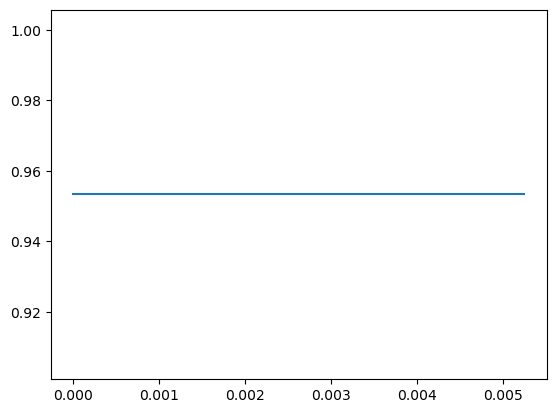

0.96


In [37]:
plt.plot(threshold, score)
plt.show()
X_embedded = SelectFromModel(rfc, threshold=0.00067).fit_transform(X, y)
X_embedded.shape
print(cross_val_score(rfc, X_embedded, y, cv=5).mean())